# GOOG Quantitative Financial Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df = pd.read_csv("../Data/GOOG.csv")

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


# Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


# Data Quality Checks

In [5]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
df = df.dropna()

# Datetime Conversion

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df = df.sort_values("Date")

# Closing Price Analysis

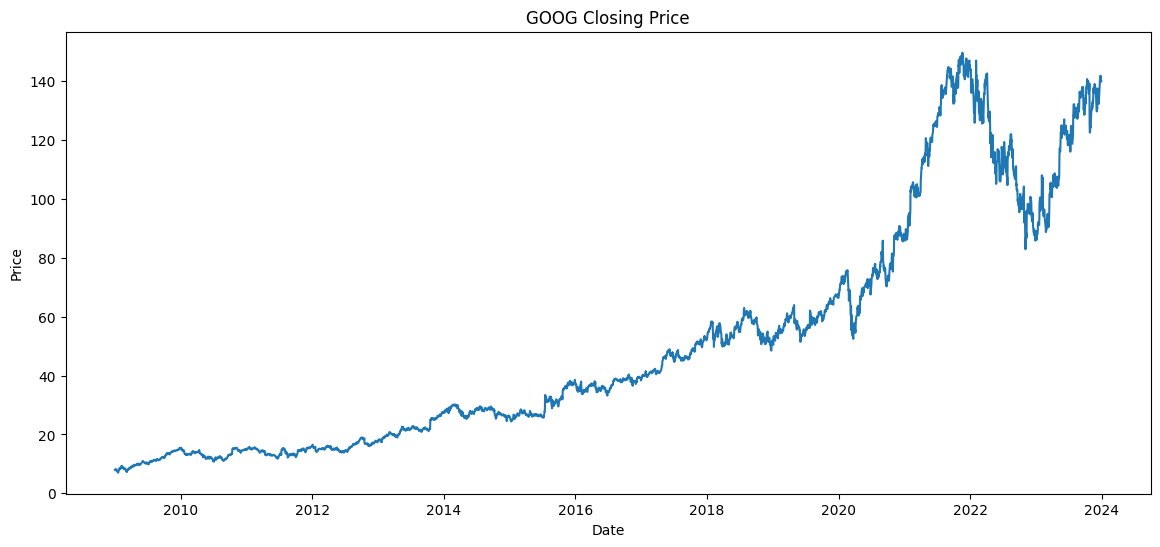

In [9]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("GOOG Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

# Simple Moving Average (SMA)

In [10]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

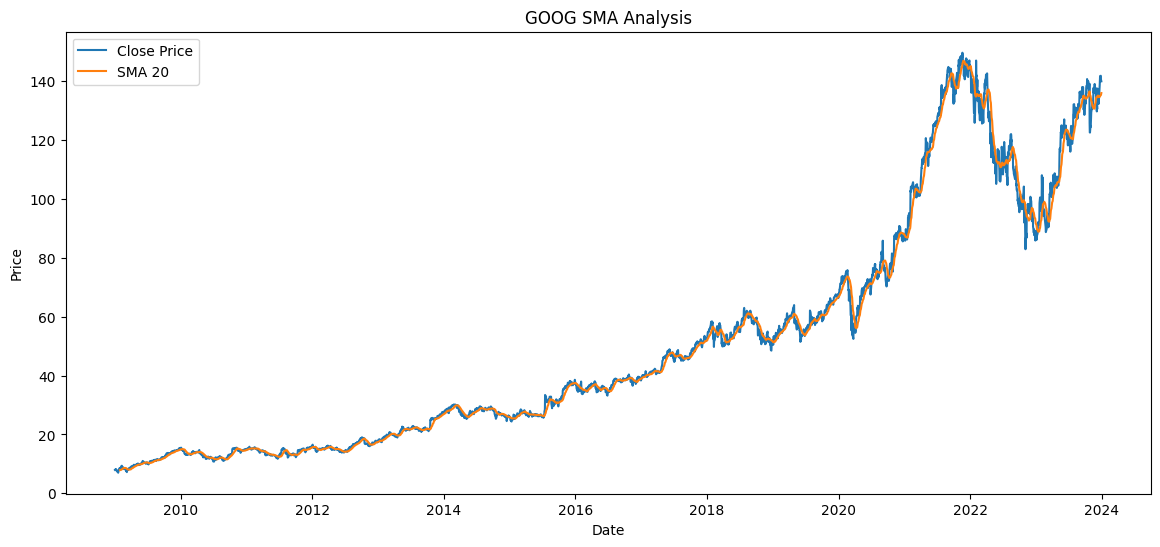

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")

plt.title("GOOG SMA Analysis")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

# Exponential Moving Average (EMA)

In [12]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

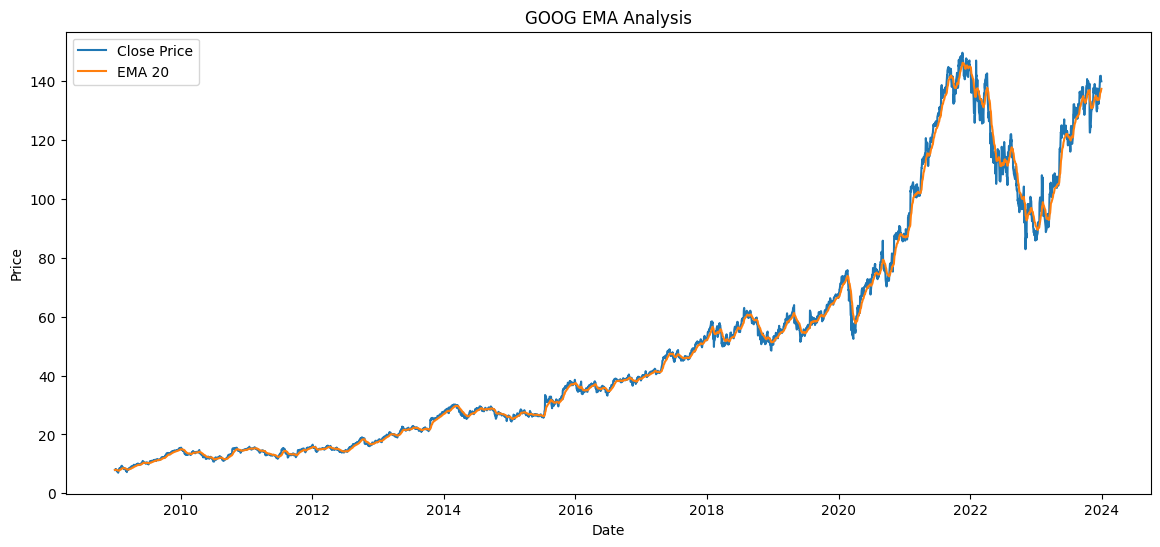

In [13]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("GOOG EMA Analysis")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

# Daily Returns

In [14]:
df["Daily_Return"] = df["Close"].pct_change()

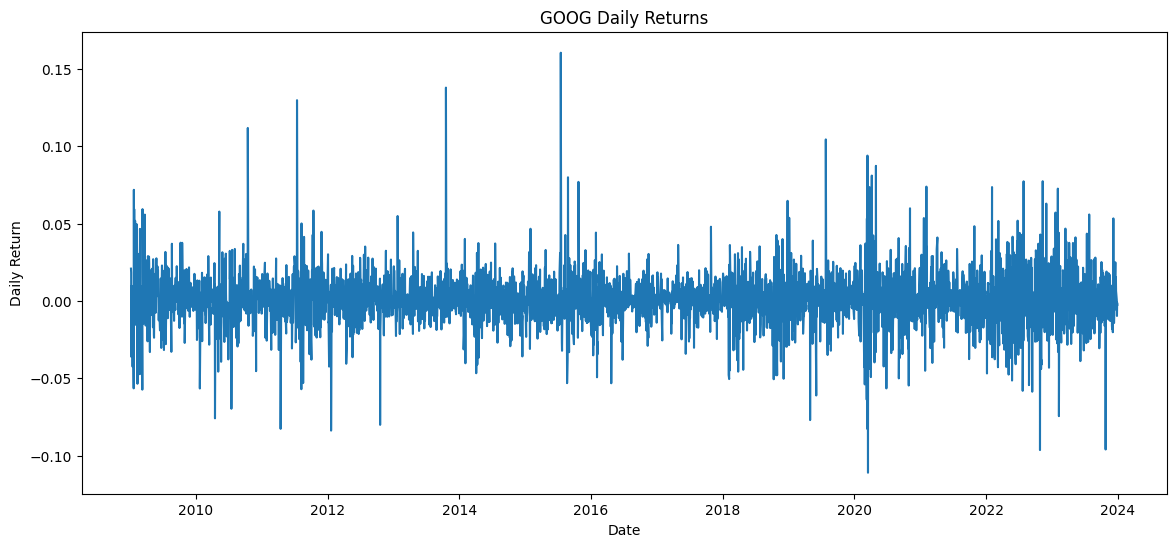

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Daily_Return"])

plt.title("GOOG Daily Returns")

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

# Volatility Analysis

In [16]:
volatility = df["Daily_Return"].std()

print("Volatility:", volatility)

Volatility: 0.017333544613474586


# Relative Strength Index (RSI)

In [17]:
delta = df["Close"].diff()

In [18]:
gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

In [19]:
avg_gain = gain.rolling(window=14).mean()

avg_loss = loss.rolling(window=14).mean()

In [20]:
rs = avg_gain / avg_loss

In [21]:
df["RSI"] = 100 - (100 / (1 + rs))

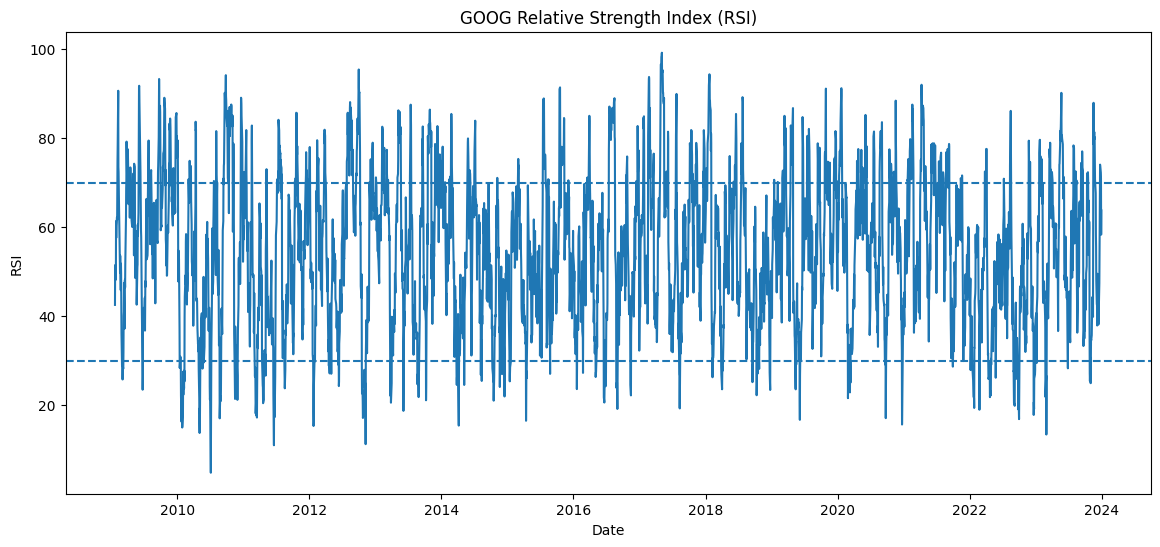

In [22]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("GOOG Relative Strength Index (RSI)")

plt.xlabel("Date")
plt.ylabel("RSI")

plt.show()

# Moving Average Convergence Divergence (MACD)

In [23]:
ema_12 = df["Close"].ewm(span=12, adjust=False).mean()

ema_26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26

In [24]:
df["Signal_Line"] = df["MACD"].ewm(span=9, adjust=False).mean()

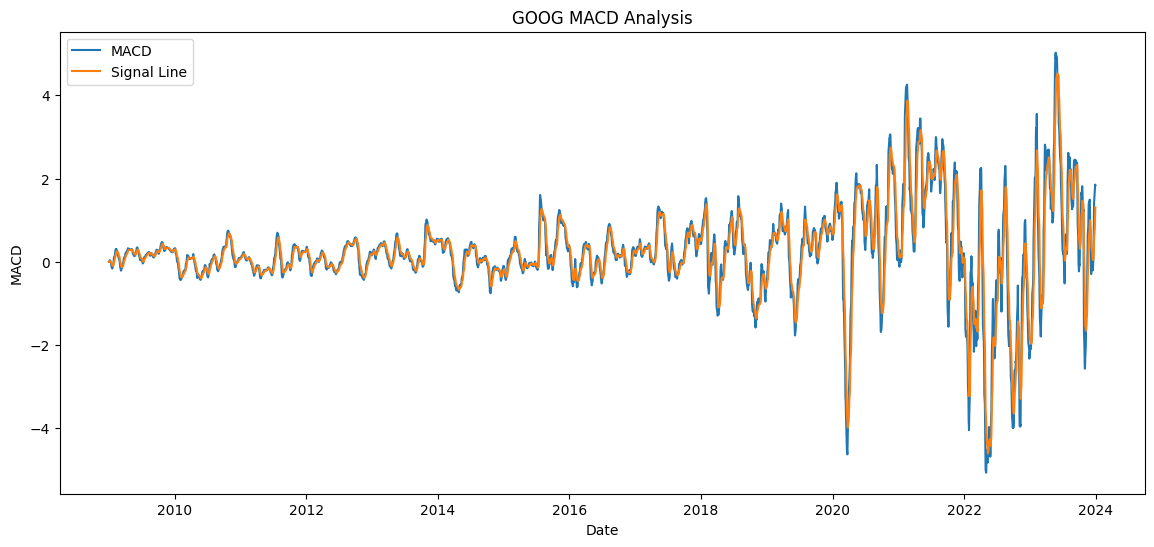

In [25]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["MACD"], label="MACD")

plt.plot(
    df["Date"],
    df["Signal_Line"],
    label="Signal Line"
)

plt.title("GOOG MACD Analysis")

plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()

plt.show()

# RSI Using TA-Lib

In [26]:
import sys
print(sys.executable)

c:\Users\nbe\Documents\news-sentiment-analysis\venv\Scripts\python.exe


In [27]:
import talib

In [28]:
df["RSI_TALIB"] = talib.RSI(
    df["Close"],
    timeperiod=14
)

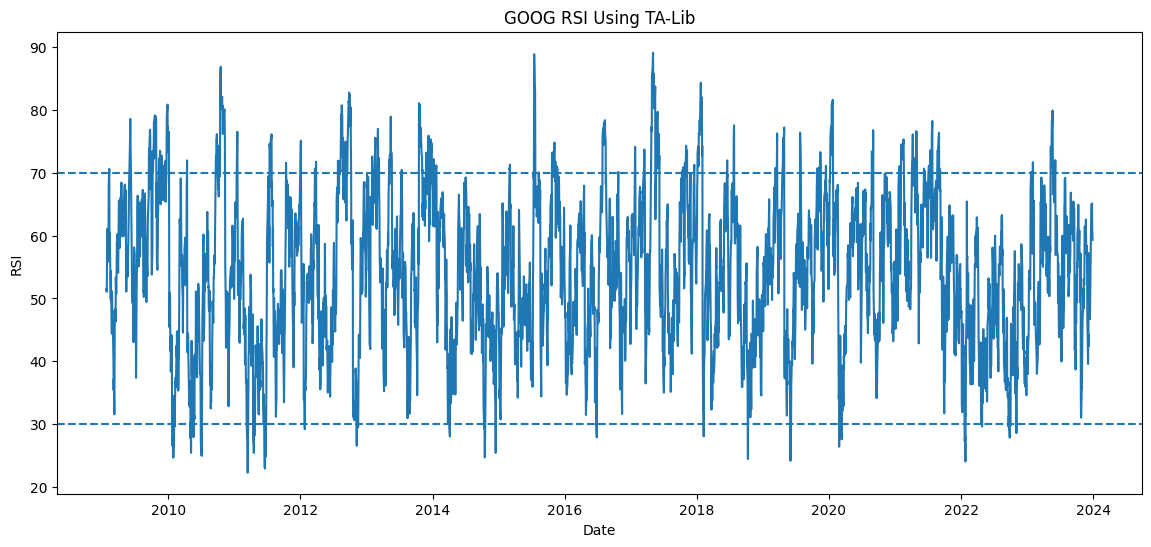

In [29]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["RSI_TALIB"])

plt.axhline(70, linestyle="--")
plt.axhline(30, linestyle="--")

plt.title("GOOG RSI Using TA-Lib")

plt.xlabel("Date")
plt.ylabel("RSI")

plt.show()

# Key Findings

- GOOG stock showed long-term upward trends with periods of volatility.
- SMA and EMA helped identify overall market direction.
- RSI highlighted overbought and oversold periods.
- MACD showed momentum changes and possible trend reversals.
- Daily return analysis demonstrated fluctuations in market performance.